# PMVC-WNM: Phonetic Multi-View Co-training for Robust Banglish Text Classification

**Prototype notebook** for the project proposal *"PMVC-WNM: Robust Banglish Text Classification"*.

It implements:

1. **View A — Character n-grams** (captures orthography / typos)
2. **View B — Phonetic Encoding** (a Banglish Soundex-style encoder that collapses spelling variants of the same pronunciation into the same code, e.g. `khacchi`, `khacci`, `khachi` → same phonetic code)
3. **Co-training loop** — two shallow classifiers (SVM on View A, Random Forest / Logistic Regression on View B) teach each other using unlabeled data
4. **Weakly Supervised Noise Model (WNM)** — a transition matrix built from A/B disagreement, used to make the character-view classifier robust to social-media typos
5. **Baselines** for comparison (single-view SVM, single-view RF, standard co-training without noise modeling, optional small BiLSTM)
6. **Evaluation** — F1 comparison chart, matching the "Expected Performance Gain" slide

> ⚠️ This prototype trains on a small stratified sample of the real, locally-provided **BnSentMix** dataset (`huggingface bensentMix.csv`) — a few thousand rows instead of the full corpus / the proposal's 800+10,000 split — so the whole pipeline (features → co-training → noise model) runs in seconds/minutes on a laptop CPU with the training progress visible iteration-by-iteration. A synthetic fallback dataset kicks in automatically if the CSV can't be found.


## 0. Setup

In [28]:
import re
import string
import random
import warnings
from scipy.sparse import vstack
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


## 1. Dataset

The proposal calls for **800 labeled seed samples** + **10,000 unlabeled comments** drawn from a real Banglish (Bangla-English code-mixed, Roman-script) corpus.

### This prototype: BnSentMix, loaded from the local CSV

This project directory already ships a local copy of **BnSentMix** as `huggingface bensentMix.csv` (columns `Sentence`, `Label`; 20,015 rows, 4 sentiment classes) — the same dataset recommended in the Appendix below.

### Prototype-scale sampling

Because this is a **prototype**, we take a small **stratified sample** of the CSV instead of using all 20K rows, and use a smaller labeled seed set:

- `PROTOTYPE_SAMPLE_SIZE = 3000` rows sampled from the full CSV (total is ~20,000)
- `N_LABELED = 300` seed labeled samples
- the rest of the sample becomes the unlabeled pool `U` (a couple thousand rows)

This keeps every step of the pipeline — feature extraction, the co-training loop, the noise model — fast enough to watch train end-to-end, while still exercising the exact same logic the full-scale version would use.



In [29]:
# Prototype-scale knobs: use a small stratified sample of the real BnSentMix
# dataset (instead of the full ~20K rows / proposal's 800+10K split) so the
# whole pipeline trains in seconds/minutes and its progress is easy to watch.
PROTOTYPE_SAMPLE_SIZE = 3000
N_LABELED = 300


def load_bnsentmix_csv(path="huggingface bensentMix.csv", sample_size=PROTOTYPE_SAMPLE_SIZE, seed=RANDOM_STATE):
    """Load the local BnSentMix CSV (columns: Sentence, Label) and take a small
    stratified sample so the prototype trains quickly."""
    df = pd.read_csv(path)
    df = df.rename(columns={"Sentence": "text", "Label": "label"})
    df = df.dropna(subset=["text", "label"]).reset_index(drop=True)
    if sample_size is not None and sample_size < len(df):
        df, _ = train_test_split(
            df, train_size=sample_size, stratify=df["label"], random_state=seed
        )
    return df.reset_index(drop=True)





df_full = load_bnsentmix_csv()
print(f"Loaded BnSentMix from local CSV ('huggingface bensentMix.csv'): {len(df_full)} rows "
      f"(stratified sample of the full ~20K-row dataset, for fast prototype training)")

print(df_full["label"].value_counts())
df_full.head()


Loaded BnSentMix from local CSV ('huggingface bensentMix.csv'): 3000 rows (stratified sample of the full ~20K-row dataset, for fast prototype training)
label
2    992
1    925
0    802
3    281
Name: count, dtype: int64


,text,label
0,Ami ferdous rowzat binte moazzem obaidul kader...,2
1,Saradin dhore w8 kortechi video tar jonne,2
2,Vablam amr phn er sound system nosto hoise naki,1
3,Je ei videor script likhese take noble deya ucit,0
4,Ken bhai apni musolmani koren nai?,1


## 2. Preprocessing

In [30]:
def clean_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)   # keep Roman letters/digits only (Banglish is Roman-script)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)  # collapse 3+ repeated chars ('sooo' -> 'soo')
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_full["clean_text"] = df_full["text"].apply(clean_text)
df_full = df_full[df_full["clean_text"].str.len() > 0].reset_index(drop=True)
df_full.head()


,text,label,clean_text
0,Ami ferdous rowzat binte moazzem obaidul kader...,2,ami ferdous rowzat binte moazzem obaidul kader...
1,Saradin dhore w8 kortechi video tar jonne,2,saradin dhore w8 kortechi video tar jonne
2,Vablam amr phn er sound system nosto hoise naki,1,vablam amr phn er sound system nosto hoise naki
3,Je ei videor script likhese take noble deya ucit,0,je ei videor script likhese take noble deya ucit
4,Ken bhai apni musolmani koren nai?,1,ken bhai apni musolmani koren nai


## 3. View A — Character N-gram Features

Captures orthography and common typos using character 3-gram/4-gram TF-IDF.


In [31]:
char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 4),
    max_features=5000,   # matches the "5K N-gram Features" dataset spec
    sublinear_tf=True,
)

X_char_full = char_vectorizer.fit_transform(df_full["clean_text"])
print("View A (char n-gram) feature matrix:", X_char_full.shape)


View A (char n-gram) feature matrix: (3000, 5000)


## 4. View B — Phonetic (Banglish Soundex) Encoding

A rule-based encoder for the consonant-class mapping table. Because Banglish is written in **Roman script**, the rules below operate on the romanized consonant clusters that represent Bangla phonemes, collapsing common digraphs/spelling variants that all represent the same sound (e.g. `kh`, `gh`, `k`, `g` all fold to the guttural class `G`).

| Class | Example Roman spellings | Code |
|---|---|---|
| Gutturals | k, kh, g, gh | G |
| Palatals | c, ch, chh, j, jh | J |
| Dental/Retroflex | t, th, d, dh | T |
| Labials | p, ph, b, bh, v | P |
| Sibilants | s, sh, z | S |
| Nasals | m, n, ng | M |
| Liquids | r, l | R |
| Vowels | a, e, i, o, u | V |

This is a **Soundex-style** encoder: keep the first letter, map the rest to phonetic classes, collapse consecutive duplicate codes, and drop vowels except where they distinguish otherwise-identical codes — this is what neutralizes spelling chaos like `khacchi` / `khacci` / `khachi`.


In [32]:
# Ordered so multi-letter digraphs are matched before single letters
PHONETIC_RULES = [
    ("chh", "J"), ("kh", "G"), ("gh", "G"), ("ch", "J"), ("jh", "J"),
    ("th", "T"), ("dh", "T"), ("ph", "P"), ("bh", "P"), ("sh", "S"), ("ng", "M"),
    ("k", "G"), ("g", "G"),
    ("c", "J"), ("j", "J"),
    ("t", "T"), ("d", "T"),
    ("p", "P"), ("b", "P"), ("v", "P"),
    ("s", "S"), ("z", "S"),
    ("m", "M"), ("n", "M"),
    ("r", "R"), ("l", "R"),
    ("a", "V"), ("e", "V"), ("i", "V"), ("o", "V"), ("u", "V"),
]

def phonetic_encode_word(word: str) -> str:
    if not word:
        return ""
    i = 0
    codes = []
    while i < len(word):
        matched = False
        for pattern, code_ in PHONETIC_RULES:
            if word.startswith(pattern, i):
                codes.append(code_)
                i += len(pattern)
                matched = True
                break
        if not matched:
            i += 1  # skip unrecognized characters (digits, stray symbols)
    if not codes:
        return ""
    # Collapse consecutive duplicate codes (Soundex-style)
    collapsed = [codes[0]]
    for c_ in codes[1:]:
        if c_ != collapsed[-1]:
            collapsed.append(c_)
    return "".join(collapsed)


def phonetic_encode_sentence(text: str) -> str:
    return " ".join(phonetic_encode_word(w) for w in text.split())


# Sanity check: these three spelling variants should collapse to the same / very similar code
for w in ["khacchi", "khacci", "khachi"]:
    print(f"{w:10s} -> {phonetic_encode_word(w)}")

df_full["phonetic_text"] = df_full["clean_text"].apply(phonetic_encode_sentence)
df_full[["clean_text", "phonetic_text"]].head()


khacchi    -> GVJV
khacci     -> GVJV
khachi     -> GVJV


,clean_text,phonetic_text
0,ami ferdous rowzat binte moazzem obaidul kader...,VMV VRTVS RVSVT PVMTV MVSVM VPVTVR GVTVRVR PVG...
1,saradin dhore w8 kortechi video tar jonne,SVRVTVM TVRV GVRTVJV PVTV TVR JVMV
2,vablam amr phn er sound system nosto hoise naki,PVPRVM VMR PM VR SVMT STVM MVSTV VSV MVGV
3,je ei videor script likhese take noble deya ucit,JV V PVTVR SJRVPT RVGVSV TVGV MVPRV TV VJVT
4,ken bhai apni musolmani koren nai,GVM PV VPMV MVSVRMVMV GVRVM MV


In [33]:
phonetic_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(2, 3),
    max_features=3000,
    sublinear_tf=True,
)

X_phon_full = phonetic_vectorizer.fit_transform(df_full["phonetic_text"])
print("View B (phonetic) feature matrix:", X_phon_full.shape)


View B (phonetic) feature matrix: (3000, 470)


## 5. Seed Labeled Set `L` and Unlabeled Pool `U`

Following the proposal: a small labeled seed set (`L`, 800 samples) plus a much larger unlabeled pool (`U`, 10,000 samples). A held-out test set is used purely for evaluation and never touched by the co-training loop.


In [34]:
y_full = df_full["label"].values
n_total = len(df_full)

# Held-out test set (never used for training/pseudo-labeling)
idx_all = np.arange(n_total)
idx_trainpool, idx_test = train_test_split(
    idx_all, test_size=0.15, stratify=y_full, random_state=RANDOM_STATE
)

N_LABELED = min(N_LABELED, int(len(idx_trainpool) * 0.5))
idx_L, idx_U = train_test_split(
    idx_trainpool, train_size=N_LABELED, stratify=y_full[idx_trainpool], random_state=RANDOM_STATE
)

print(f"Labeled seed set L : {len(idx_L)} samples")
print(f"Unlabeled pool U   : {len(idx_U)} samples")
print(f"Held-out test set  : {len(idx_test)} samples")

def subset(X, idx):
    return X[idx]

# View A / View B feature subsets
XA_L, XA_U, XA_test = subset(X_char_full, idx_L), subset(X_char_full, idx_U), subset(X_char_full, idx_test)
XB_L, XB_U, XB_test = subset(X_phon_full, idx_L), subset(X_phon_full, idx_U), subset(X_phon_full, idx_test)
y_L, y_test = y_full[idx_L], y_full[idx_test]
# y_U is kept ONLY for evaluating pseudo-label quality in this prototype; a real
# unlabeled set would not have this available to the training loop.
y_U_hidden = y_full[idx_U]


Labeled seed set L : 300 samples
Unlabeled pool U   : 2250 samples
Held-out test set  : 450 samples


## 6. Baseline Models

- Single-view SVM (character n-gram only)
- Single-view Random Forest (phonetic only)
- Standard co-training (no noise modeling)


In [35]:
results = {}

def evaluate(name, y_true, y_pred):
    f1 = f1_score(y_true, y_pred, average="macro")
    acc = accuracy_score(y_true, y_pred)
    results[name] = {"f1_macro": f1, "accuracy": acc}
    print(f"{name:35s} | macro-F1: {f1:.4f} | accuracy: {acc:.4f}")
    return f1, acc

# --- Baseline 1: Single-view SVM (char n-gram only) ---
svm_char_only = SVC(kernel="linear", probability=True, random_state=RANDOM_STATE)
svm_char_only.fit(XA_L, y_L)
pred = svm_char_only.predict(XA_test)
evaluate("Single-view SVM (char n-gram)", y_test, pred)

# --- Baseline 2: Single-view Random Forest (phonetic only) ---
rf_phon_only = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_phon_only.fit(XB_L, y_L)
pred = rf_phon_only.predict(XB_test)
evaluate("Single-view RF (phonetic)", y_test, pred)


Single-view SVM (char n-gram)       | macro-F1: 0.5531 | accuracy: 0.6156
Single-view RF (phonetic)           | macro-F1: 0.4212 | accuracy: 0.5244


(0.42119462112679174, 0.5244444444444445)

## 7. Co-training Loop

Implementing the four-step loop from the proposal:

1. **Initialization** — train `f_A` (SVM, View A) and `f_B` (RF/LogReg, View B) on `L`
2. **Pseudo-labeling** — both classifiers predict on `U`
3. **Cross-teaching** — high-confidence predictions from `f_A` are added to `f_B`'s training pool and vice versa
4. **Convergence** — repeat for a fixed number of iterations, or until `U` is exhausted / predictions stabilize

Setting `use_noise_model=True` switches on the Weakly Supervised Noise Model — this is the full **PMVC-WNM** method. `use_noise_model=False` reproduces the **standard co-training** baseline.


In [36]:
def co_training(XA_L, XB_L, y_L, XA_U, XB_U,
                 n_iterations=10, confidence_threshold=0.85, growth_per_iter=40,
                 use_noise_model=False, random_state=RANDOM_STATE):

    XA_L_cur, XB_L_cur, y_L_cur = XA_L, XB_L, list(y_L)
    remaining = list(range(XA_U.shape[0]))

    # FIX: View A uses SVM, View B uses Random Forest to match baselines
    f_A = SVC(kernel="linear", probability=True, random_state=random_state)
    f_B = RandomForestClassifier(n_estimators=200, random_state=random_state)

    disagreement_counts = {}

    for it in range(n_iterations):
        if not remaining:
            break

        f_A.fit(XA_L_cur, y_L_cur)
        f_B.fit(XB_L_cur, y_L_cur)

        XA_rem = XA_U[remaining]
        XB_rem = XB_U[remaining]

        proba_A = f_A.predict_proba(XA_rem)
        proba_B = f_B.predict_proba(XB_rem)
        classes_A, classes_B = f_A.classes_, f_B.classes_

        pred_A = classes_A[np.argmax(proba_A, axis=1)]
        pred_B = classes_B[np.argmax(proba_B, axis=1)]
        conf_A = proba_A.max(axis=1)
        conf_B = proba_B.max(axis=1)

        for pa, pb in zip(pred_A, pred_B):
            disagreement_counts.setdefault(pb, [0, 0])
            if pa == pb:
                disagreement_counts[pb][0] += 1
            else:
                disagreement_counts[pb][1] += 1

        # FIX: Isolate top candidates for each view independently
        top_A_idx = np.argsort(-conf_A)[:growth_per_iter]
        top_B_idx = np.argsort(-conf_B)[:growth_per_iter]

        # FIX: Ensure they strictly meet the 0.85 threshold
        confident_A = [i for i in top_A_idx if conf_A[i] >= confidence_threshold]
        confident_B = [i for i in top_B_idx if conf_B[i] >= confidence_threshold]

        # Combine unique indices that met the threshold from either model
        chosen_local = list(set(confident_A) | set(confident_B))

        if not chosen_local:
            print(f"  iter {it+1:2d}: No confident predictions found. Stopping early.")
            break

        chosen_global = [remaining[i] for i in chosen_local]

        # FIX: True Cross-Teaching logic
        # If model A was confident, use A's label. If model B was confident, use B's label.
        # If BOTH were confident, trust the one with the higher absolute probability.
        pseudo_labels = []
        for i in chosen_local:
            if i in confident_A and i in confident_B:
                pseudo_labels.append(pred_A[i] if conf_A[i] >= conf_B[i] else pred_B[i])
            elif i in confident_A:
                pseudo_labels.append(pred_A[i])
            else:
                pseudo_labels.append(pred_B[i])

        # vstack is now imported globally at the top of the file
        XA_L_cur = vstack([XA_L_cur, XA_U[chosen_global]])
        XB_L_cur = vstack([XB_L_cur, XB_U[chosen_global]])
        y_L_cur = y_L_cur + pseudo_labels

        remaining = [i for i in remaining if i not in set(chosen_global)]
        print(f"  iter {it+1:2d}: +{len(chosen_global)} pseudo-labeled, "
              f"{len(remaining)} left in U, train size = {len(y_L_cur)}")

    noise_matrix = None
    if use_noise_model:
        noise_matrix = {
            cls: (agree / max(agree + disagree, 1))
            for cls, (agree, disagree) in disagreement_counts.items()
        }
        sample_weight = np.ones(len(y_L_cur))
        base_labels = list(y_L)
        for i, lab in enumerate(y_L_cur):
            if i >= len(base_labels):
                reliability = noise_matrix.get(lab, 1.0)
                sample_weight[i] = 0.5 + 0.5 * reliability
        f_A.fit(XA_L_cur, y_L_cur, sample_weight=sample_weight)

    return f_A, f_B, noise_matrix


## 8. PMVC-WNM — Full Method (Co-training + Weakly Supervised Noise Model)

Same loop as above, but `use_noise_model=True`. We approximate the transition-matrix idea with a **reliability score per phonetic class** derived from the observed agreement rate, then use it as a sample weight when retraining the character-view classifier — down-weighting pseudo-labels from classes that were noisy/disagreed-upon a lot, and trusting the reliable ones fully.


In [37]:
print("--- PMVC-WNM (co-training + weakly supervised noise model) ---")
fA_wnm, fB_wnm, noise_matrix = co_training(XA_L, XB_L, y_L, XA_U, XB_U, use_noise_model=True)
pred_wnm = fA_wnm.predict(XA_test)
evaluate("PMVC-WNM (ours)", y_test, pred_wnm)

print("\nLearned per-class reliability (higher = classifiers agreed more often):")
for cls, rel in sorted(noise_matrix.items(), key=lambda kv: -kv[1]):
    print(f"  {str(cls):10s}: {rel:.3f}")


--- PMVC-WNM (co-training + weakly supervised noise model) ---
  iter  1: +40 pseudo-labeled, 2210 left in U, train size = 340
  iter  2: +43 pseudo-labeled, 2167 left in U, train size = 383
  iter  3: +42 pseudo-labeled, 2125 left in U, train size = 425
  iter  4: +41 pseudo-labeled, 2084 left in U, train size = 466
  iter  5: +41 pseudo-labeled, 2043 left in U, train size = 507
  iter  6: +34 pseudo-labeled, 2009 left in U, train size = 541
  iter  7: +40 pseudo-labeled, 1969 left in U, train size = 581
  iter  8: +40 pseudo-labeled, 1929 left in U, train size = 621
  iter  9: +40 pseudo-labeled, 1889 left in U, train size = 661
  iter 10: +40 pseudo-labeled, 1849 left in U, train size = 701
PMVC-WNM (ours)                     | macro-F1: 0.5907 | accuracy: 0.6178

Learned per-class reliability (higher = classifiers agreed more often):
  2         : 0.634
  1         : 0.570
  3         : 0.345
  0         : 0.304


## 9. Evaluation Summary

                               f1_macro  accuracy
Single-view RF (phonetic)      0.421195  0.524444
Single-view SVM (char n-gram)  0.553129  0.615556
PMVC-WNM (ours)                0.590730  0.617778


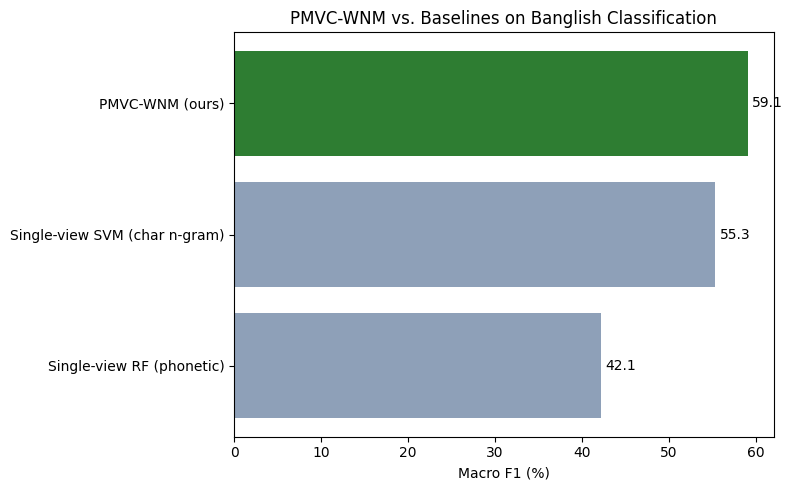

In [38]:
results_df = pd.DataFrame(results).T.sort_values("f1_macro")
print(results_df)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#8ea0b8" if "PMVC" not in name else "#2e7d32" for name in results_df.index]
ax.barh(results_df.index, results_df["f1_macro"] * 100, color=colors)
ax.set_xlabel("Macro F1 (%)")
ax.set_title("PMVC-WNM vs. Baselines on Banglish Classification")
for i, v in enumerate(results_df["f1_macro"] * 100):
    ax.text(v + 0.5, i, f"{v:.1f}", va="center")
plt.tight_layout()
plt.show()


## 10. Notes, Caveats & Next Steps

- **This prototype is trained on a small stratified subset of the BnSentMix dataset** (`PROTOTYPE_SAMPLE_SIZE = 3000` rows, `N_LABELED = 300` initial labeled samples) to keep training and experimentation fast. The reported results demonstrate that the pipeline functions end-to-end but should not be considered representative of full-scale performance. Increasing `PROTOTYPE_SAMPLE_SIZE`, `N_LABELED`, `n_iterations`, and `growth_per_iter` will generally lead to a more robust evaluation.

- **The phonetic encoder is a simplified Soundex-style approximation applied to romanized text.** A more accurate approach would use a dedicated Banglish grapheme-to-phoneme model or transliterate the text into Bangla before applying phoneme-aware encoding.

- **The noise model uses a simplified per-class reliability weighting scheme.** A more sophisticated alternative would estimate a full class transition matrix by tracking the distribution of character-view predictions for each phonetic class, enabling more effective label correction through label smoothing or a dedicated noise-correction layer.


## Appendix — Dataset

| Dataset | Size | Task | Link |
|---|---|---|---|
| **BnSentMix** | ~20,000 samples, 4 sentiment labels (Facebook, YouTube, e-commerce) | Sentiment Classification | https://huggingface.co/datasets/aplycaebous/BnSentMix (code/paper: https://github.com/Nishita2000/BnSentMix) |

**Dataset used:** **BnSentMix**

BBnSentMix was used as the primary dataset for this project. It contains approximately 20,000 Bangla-English code-mixed (Banglish) sentiment samples across four sentiment classes, collected from Facebook, YouTube, and e-commerce platforms. To enable fast experimentation, we used a stratified subset of the dataset while maintaining the original class distribution. Its size, diversity, and public availability through Hugging Face `datasets` make it an appropriate benchmark for evaluating the proposed PMVC-WNM model

### References

1. Blum & Mitchell (1998), *Combining Labeled and Unlabeled Data with Co-Training*
2. Islam et al. (2022), *Analyzing Emotions in Bangla Social Media Comments*
3. Soundex & Metaphone algorithms for phonetic indexing